# Lesson 2 — Homework

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-homework.ipynb)

**Estimated time: 3-4 hours.**

## How to work through this

Each task gives a function signature and a docstring stating exactly what
the function must return. Replace `raise NotImplementedError` with your
implementation; the cell after it asserts the behaviour.

**A failing assert is information, not a grade.** Read it, fix the
function, re-run.

The written questions are marked and they carry the real learning
objective. Each asks you to **run something both ways and explain the
difference**, using numbers you produced. One sentence will not be enough.

Every function you need is demonstrated in `2-practice.ipynb`, and each task
names the section. You should not need any other documentation.

## Before you submit

**Runtime → Restart and run all must complete without error** with every
assert passing. Then **File → Download → Download .ipynb**, rename the file to
`2-homework-results.ipynb`, and commit it to your fork under
`practice/2/`. Keep the outputs in the file; do not clear them.
The full procedure is in `practice/README.md` §8.

## 1. Setup

In [1]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python", sys.version.split()[0], "| pandas", pd.__version__, "| seaborn", sns.__version__)

python 3.13.15 | pandas 2.2.3 | seaborn 0.13.2


In [2]:
titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


In [3]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
titanic = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv")
wine = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv")
bikes = pd.read_csv("https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv")

print("titanic", titanic.shape, "| wine", wine.shape, "| bikes", bikes.shape)

titanic (891, 12) | wine (178, 14) | bikes (17379, 17)


## 2. Task 1 — A missingness report

Mechanical.

*see Practice 2 §5.1*

In [4]:
def missing_report(frame):
    """Return a DataFrame describing the missing values of `frame`.

    One row per column that has at least one missing value. Columns with
    no missing values are excluded entirely.

    Two columns, in this order:
        'missing'  the count of missing values, an integer
        'percent'  the percentage of rows missing, 0-100, rounded to 2 dp

    Sorted by 'missing', descending. The index is the original column name.
    """
    # 1. Подсчитываем количество пропусков в каждой колонке
    missing_counts = frame.isna().sum()

    # 2. Фильтруем только те колонки, где
    # пропусков больше 0
    missing_counts = missing_counts[missing_counts > 0]

    # 3. Вычисляем процент пропусков
    percent = (missing_counts / len(frame)) * 100

    # 4. Собираем DataFrame
    report = pd.DataFrame({
        'missing': missing_counts,
        'percent': percent.round(2)
    })

    # 5. Сортируем по убыванию количества пропусков

    return report.sort_values(by='missing', ascending=False)

In [5]:
_report = missing_report(titanic)

assert list(_report.columns) == ["missing", "percent"], f"columns wrong: {list(_report.columns)}"
assert len(_report) == 3, f"Titanic has three columns with gaps, you reported {len(_report)}"
assert list(_report.index) == ["Cabin", "Age", "Embarked"], \
    f"wrong columns or wrong order: {list(_report.index)}"
assert _report.loc["Cabin", "missing"] == 687
assert _report.loc["Age", "missing"] == 177
assert _report.loc["Embarked", "missing"] == 2
assert np.isclose(_report.loc["Age", "percent"], 19.87, atol=0.01), \
    f"percent should be 100 * 177/891 = 19.87, got {_report.loc['Age', 'percent']}"

# a frame with no gaps produces an empty report, not an error
assert len(missing_report(wine)) == 0, "wine.csv has no missing values"

print(_report)
print("\nTask 1 passed.")

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200

Task 1 passed.


## 3. Task 2 — Label against position

Mechanical, and the trap is real. After a sort, `.loc` and `.iloc` answer
different questions.

*see Practice 2 §4*

In [6]:
def first_and_labelled(frame, sort_column, label):
    """Sort `frame` by `sort_column` descending, then return a tuple:

        (top_row, labelled_row)

    top_row       the row now in FIRST POSITION, as a Series
    labelled_row  the row whose INDEX LABEL equals `label`, as a Series

    Do not reset the index. Both must come from the sorted frame.
    """
    sorted_df = frame.sort_values(by=sort_column, ascending=False)
    top_row = sorted_df.iloc[0]
    labelled_row = sorted_df.loc[label]
    return top_row, labelled_row

In [7]:
_top, _labelled = first_and_labelled(titanic, "Fare", 0)

assert isinstance(_top, pd.Series) and isinstance(_labelled, pd.Series)
assert np.isclose(_top["Fare"], 512.3292), \
    f"the highest fare is 512.3292, you returned {_top['Fare']}"
assert _labelled["Name"] == "Braund, Mr. Owen Harris", \
    f"label 0 is Braund, you returned {_labelled['Name']}"
assert np.isclose(_labelled["Fare"], 7.25)
assert _top["Name"] != _labelled["Name"], \
    "position 0 and label 0 must be different passengers after sorting"

print("position 0 after sorting:", _top["Name"], "| fare", round(_top["Fare"], 2))
print("label 0 after sorting   :", _labelled["Name"], "| fare", round(_labelled["Fare"], 2))
print("\nTask 2 passed.")

position 0 after sorting: Cardeza, Mr. Thomas Drake Martinez | fare 512.33
label 0 after sorting   : Braund, Mr. Owen Harris | fare 7.25

Task 2 passed.


## 4. Task 3 — Group-wise imputation, without the chained-assignment bug

Applied. Fill missing ages with the median of the passenger's
`(Pclass, Sex)` group, and do it without triggering a
`SettingWithCopyWarning`.

*see Practice 2 §4.2, §5.4 and §6.3*

In [8]:
def fill_age_by_group(frame):
    """Return a COPY of `frame` with missing 'Age' filled by the median age
    of the passenger's (Pclass, Sex) group.

    The argument must not be modified.
    The returned frame must have no missing 'Age'.
    Use groupby(...).transform(...), not a loop, and not agg.
    """
    df = frame.copy()
    age_medians = df.groupby(['Pclass', 'Sex'])['Age'].transform('median')
    df['Age'] = df['Age'].fillna(age_medians)
    return df

In [9]:
import warnings

_before_missing = int(titanic["Age"].isna().sum())

with warnings.catch_warnings():
    warnings.simplefilter("error")          # any pandas warning becomes an exception
    _filled = fill_age_by_group(titanic)

assert int(titanic["Age"].isna().sum()) == _before_missing, "the argument was modified"
assert int(_filled["Age"].isna().sum()) == 0, "some ages are still missing"
assert len(_filled) == len(titanic), "rows were added or lost"

# The ages that were already present must be untouched.
_present = titanic["Age"].notna()
assert np.allclose(_filled.loc[_present, "Age"], titanic.loc[_present, "Age"]), \
    "existing ages were altered"

# A filled passenger must receive their own group's median, not the global one.
_a_gap = titanic.index[titanic["Age"].isna()][0]
_pclass, _sex = titanic.loc[_a_gap, "Pclass"], titanic.loc[_a_gap, "Sex"]
_expected = titanic[(titanic["Pclass"] == _pclass) & (titanic["Sex"] == _sex)]["Age"].median()
assert np.isclose(_filled.loc[_a_gap, "Age"], _expected), \
    f"passenger {_a_gap} got {_filled.loc[_a_gap, 'Age']}, expected group median {_expected}"

print(f"filled {_before_missing} ages; std went from "
      f"{titanic['Age'].std():.4f} to {_filled['Age'].std():.4f}")
print("Task 3 passed.")

filled 177 ages; std went from 14.5265 to 13.3044
Task 3 passed.


## 5. Task 4 — Four imputations, four distributions

Applied.

*see Practice 2 §5.4*

In [10]:
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values."""

    col_data = frame[column]

    # 1. Видалення пропущених значень
    s_dropna = col_data.dropna()

    # 2. Заповнення середнім значенням
    s_mean = col_data.fillna(col_data.mean())

    # 3. Заповнення медіаною
    s_median = col_data.fillna(col_data.median())

    # 4. Заповнення медіаною за групами Pclass і Sex
    group_medians = frame.groupby(
        ["Pclass", "Sex"]
    )[column].transform("median")

    s_group_median = col_data.fillna(group_medians)

    def get_stats(series):
        return {
            "n": series.count(),
            "mean": series.mean(),
            "median": series.median(),
            "std": series.std()
        }

    data = {
        "dropna": get_stats(s_dropna),
        "mean": get_stats(s_mean),
        "median": get_stats(s_median),
        "group_median": get_stats(s_group_median)
    }

    result = pd.DataFrame(data).T

    return result[["n", "mean", "median", "std"]]

In [11]:
_comparison = compare_imputations(titanic)

assert list(_comparison.index) == ["dropna", "mean", "median", "group_median"]
assert list(_comparison.columns) == ["n", "mean", "median", "std"]
assert _comparison.loc["dropna", "n"] == 714, "dropna keeps the 714 recorded ages"
assert _comparison.loc["mean", "n"] == 891, "filling keeps all 891 rows"

# Filling with the mean preserves the mean exactly and shrinks the spread.
assert np.isclose(_comparison.loc["mean", "mean"], titanic["Age"].mean()), \
    "filling with the mean must leave the mean unchanged"
assert _comparison.loc["mean", "std"] < _comparison.loc["dropna", "std"], \
    "stacking 177 rows on one value must reduce the standard deviation"

# The group-wise fill distorts the spread less than a single constant does.
assert _comparison.loc["group_median", "std"] > _comparison.loc["mean", "std"], \
    "the group-wise fill should preserve more of the spread than a constant fill"

print(_comparison.round(4))
print("\nTask 4 passed.")
def compare_imputations(frame, column="Age"):
    """Return a DataFrame comparing four ways of handling missing values."""
    col_data = frame[column]

    # 1. Strategy: dropna
    s_dropna = col_data.dropna()

    # 2. Strategy: mean
    s_mean = col_data.fillna(col_data.mean())

    # 3. Strategy: median
    s_median = col_data.fillna(col_data.median())

    # 4. Strategy: group_median
    group_medians = frame.groupby(['Pclass', 'Sex'])[column].transform('median')
    s_group_median = col_data.fillna(group_medians)

    def get_stats(series):
        return {
            'n': series.count(),
            'mean': series.mean(),
            'median': series.median(),
            'std': series.std()
        }

    data = {
        'dropna': get_stats(s_dropna),
        'mean': get_stats(s_mean),
        'median': get_stats(s_median),
        'group_median': get_stats(s_group_median)
    }

    result = pd.DataFrame(data).T
    return result[['n', 'mean', 'median', 'std']]

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044

Task 4 passed.


### Question 1 — choosing an imputation

Using the table you just produced, and a histogram of each of the four
resulting distributions:

**(a)** Filling with the mean leaves the mean **exactly** unchanged and
still damages the data. What quantity did it damage, by how much, and why
does preserving the mean not make the fill harmless?

**(b)** Compare `dropna` with the three fills. Dropping loses 177 rows,
20 % of the data. Under what condition about *why* the values are missing
is dropping unbiased, and is that condition plausible for Titanic's `Age`?
Name the MCAR / MAR / MNAR category you think applies and give your
evidence.

**(c)** You must pick one strategy and defend it to a reviewer. Pick one
and write the defence in three sentences.

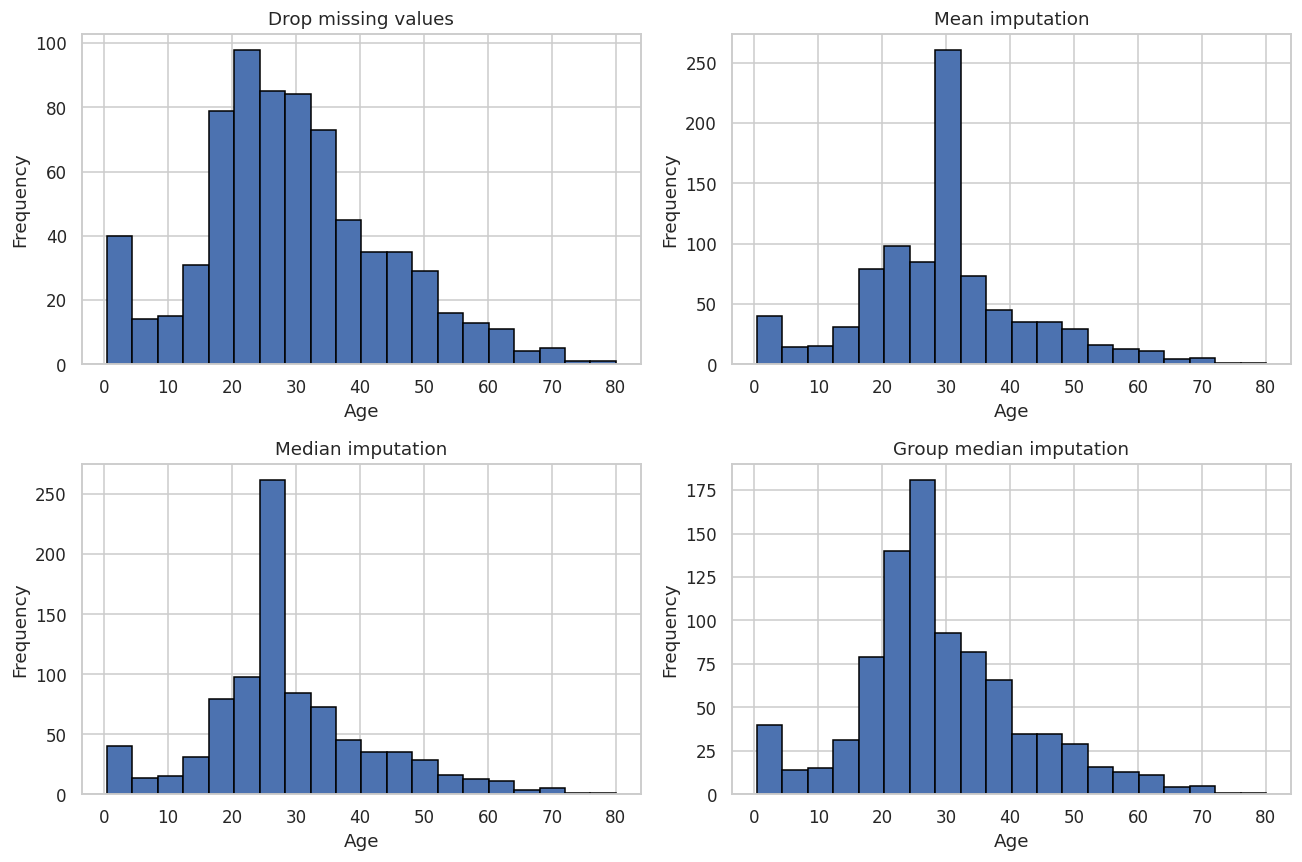

                    n    mean  median     std
dropna       714.0000 29.6991 28.0000 14.5265
mean         891.0000 29.6991 29.6991 13.0020
median       891.0000 29.3616 28.0000 13.0197
group_median 891.0000 29.1124 26.0000 13.3044


In [12]:
# Space for the code that suimport matplotlib.pyplot as pltpports your answer.

age = titanic["Age"]

# Four imputation strategies
age_dropna = age.dropna()
age_mean = age.fillna(age.mean())
age_median = age.fillna(age.median())

group_medians = titanic.groupby(
    ["Pclass", "Sex"]
)["Age"].transform("median")

age_group_median = age.fillna(group_medians)

# Plot histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].hist(age_dropna, bins=20, edgecolor="black")
axes[0, 0].set_title("Drop missing values")

axes[0, 1].hist(age_mean, bins=20, edgecolor="black")
axes[0, 1].set_title("Mean imputation")

axes[1, 0].hist(age_median, bins=20, edgecolor="black")
axes[1, 0].set_title("Median imputation")

axes[1, 1].hist(age_group_median, bins=20, edgecolor="black")
axes[1, 1].set_title("Group median imputation")

for ax in axes.flat:
    ax.set_xlabel("Age")
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Display comparison table
print(_comparison.round(4))

**Your answer:**

(a) Mean imputation keeps the mean unchanged, but it reduces the standard deviation from 14.5265 to 13.0020. This happens because all 177 missing Age values are replaced with the same mean value, creating an artificial peak around 29.7 years. Therefore, preserving the mean does not make the method harmless because the variability and shape of the distribution are changed.

(b) Dropping missing values is unbiased only when the missingness is completely independent of the data, which corresponds to MCAR (Missing Completely At Random). For Titanic's Age variable, this assumption may not be plausible because missing ages can be related to observed characteristics such as passenger class or sex. Therefore, MAR (Missing At Random) is a more reasonable assumption than MCAR.

(c) I would choose group-median imputation based on Pclass and Sex. It keeps all 891 observations and uses passenger characteristics when estimating missing ages instead of assigning one identical value to everyone. This reduces the artificial distortion of the Age distribution compared with simple mean or median imputation.

## 6. Task 5 — The IQR rule

Applied. Implement the rule behind a boxplot's whiskers.

*see Practice 2 §10.4*

In [13]:
def iqr_outliers(series, multiplier=1.5):
    """Flag the values of `series` outside the 1.5 x IQR fences.

    Q1 and Q3 are the 25th and 75th percentiles; IQR = Q3 - Q1.
    The fences are Q1 - multiplier*IQR and Q3 + multiplier*IQR.
    A value strictly outside either fence is an outlier.

    Missing values are never outliers.

    Return a dict with exactly these five keys:
        'q1', 'q3', 'lower', 'upper'   the four numbers, as floats
        'mask'  a boolean Series aligned to `series`, True where outlying
    """
    clean = series.dropna()

    q1 = float(clean.quantile(0.25))
    q3 = float(clean.quantile(0.75))

    iqr = q3 - q1

    lower = float(q1 - multiplier * iqr)
    upper = float(q3 + multiplier * iqr)

    mask = ((series < lower) | (series > upper)).fillna(False)

    return {
        'q1': q1,
        'q3': q3,
        'lower': lower,
        'upper': upper,
        'mask': mask
    }

In [14]:
_fare = iqr_outliers(titanic["Fare"], multiplier=1.5)

assert set(_fare) == {"q1", "q3", "lower", "upper", "mask"}
assert np.isclose(_fare["q1"], 7.9104, atol=1e-3), f"Q1 wrong: {_fare['q1']}"
assert np.isclose(_fare["q3"], 31.0, atol=1e-6), f"Q3 wrong: {_fare['q3']}"
assert np.isclose(_fare["upper"], 65.6344, atol=1e-3), f"upper fence wrong: {_fare['upper']}"
assert _fare["mask"].dtype == bool
assert int(_fare["mask"].sum()) == 116, \
    f"the 1.5 x IQR rule flags 116 fares, you found {int(_fare['mask'].sum())}"

# A larger multiplier can never flag more points.
assert iqr_outliers(titanic["Fare"], 3.0)["mask"].sum() <= _fare["mask"].sum()

# Missing values must not be flagged.
_age_flags = iqr_outliers(titanic["Age"])["mask"]
assert not _age_flags[titanic["Age"].isna()].any(), "a missing value is not an outlier"
assert len(_age_flags) == len(titanic), "the mask must align to the input"

print(f"Fare: Q1 {_fare['q1']:.2f}, Q3 {_fare['q3']:.2f}, "
      f"fences [{_fare['lower']:.2f}, {_fare['upper']:.2f}], {int(_fare['mask'].sum())} flagged")
print("Task 5 passed.")

Fare: Q1 7.91, Q3 31.00, fences [-26.72, 65.63], 116 flagged
Task 5 passed.


### Question 2 — the multiplier, and two rules that disagree

**(a)** Run `iqr_outliers` on `Fare` at multipliers 1.0, 1.5, 3.0 and 5.0
and report the count at each. Then compute the 3σ count from Practice 1
§4.7 on the same column. Tabulate all five numbers.

**(b)** The IQR rule and the 3σ rule disagree sharply on `Fare`. Explain
*why*, referring to the shape of the distribution. Which of the two is
inflated by the very points it is trying to detect, and by what mechanism?

**(c)** Now run both rules on `Age` instead. Do they still disagree as
much? What is different about `Age` that changes the answer?

**(d)** For `Fare`, would you remove any of the flagged points? Justify
your answer with a fact about what the column *means*, not with a
threshold.

In [15]:
# Space for the code that supports your answer.
# Question 2: compare IQR and 3-sigma rules

# IQR counts for Fare
multipliers = [1.0, 1.5, 3.0, 5.0]

print("Fare — IQR rule")
for m in multipliers:
    result = iqr_outliers(titanic["Fare"], multiplier=m)
    print(f"Multiplier {m}: {int(result['mask'].sum())} outliers")

# 3-sigma rule
def sigma_outliers(series):
    clean = series.dropna()
    mean = clean.mean()
    std = clean.std()

    lower = mean - 3 * std
    upper = mean + 3 * std

    mask = ((series < lower) | (series > upper)).fillna(False)
    return mask

fare_sigma = sigma_outliers(titanic["Fare"])

print("\nFare — 3-sigma rule")
print("3-sigma:", int(fare_sigma.sum()), "outliers")

# Compare both rules for Age
age_iqr = iqr_outliers(titanic["Age"], multiplier=1.5)
age_sigma = sigma_outliers(titanic["Age"])

print("\nAge")
print("IQR 1.5:", int(age_iqr["mask"].sum()), "outliers")
print("3-sigma:", int(age_sigma.sum()), "outliers")

Fare — IQR rule
Multiplier 1.0: 141 outliers
Multiplier 1.5: 116 outliers
Multiplier 3.0: 53 outliers
Multiplier 5.0: 31 outliers

Fare — 3-sigma rule
3-sigma: 20 outliers

Age
IQR 1.5: 11 outliers
3-sigma: 2 outliers


**Your answer:**

(a) The IQR rule gives the following results for Fare:

Multiplier 1.0: 141 outliers
Multiplier 1.5: 116 outliers
Multiplier 3.0: 53 outliers
Multiplier 5.0: 31 outliers
3-sigma rule: 20 outliers

Thus, increasing the IQR multiplier makes the rule less sensitive and reduces the number of observations classified as outliers.

(b) The IQR rule and the 3-sigma rule disagree strongly for Fare because the Fare distribution is highly right-skewed, with a long upper tail and some very large legitimate values. The 3-sigma rule depends on the mean and standard deviation, both of which are affected by extreme values. Large fares pull the mean upward and inflate the standard deviation, which widens the 3-sigma limits and causes fewer extreme observations to be flagged. The IQR rule is more robust because quartiles are much less affected by extreme values.

(c) For Age, the 1.5 × IQR rule identifies 11 outliers, while the 3-sigma rule identifies only 2. The disagreement is therefore smaller than for Fare. Age has a much less strongly right-skewed distribution and a more limited range, so extreme values have less influence on the mean and standard deviation.

(d) I would not automatically remove the observations flagged as outliers in Fare. Fare represents the amount paid for a passenger ticket, so unusually high values can be genuine observations, for example tickets associated with expensive accommodation or bookings covering more than one passenger. Therefore, a high Fare is not by itself evidence of a data error, and flagged observations should be investigated rather than removed solely because they exceed a statistical threshold.

## 7. Task 6 — Pearson against Spearman

Applied. Two coefficients, two different questions about the same pair of
columns.

*see Practice 2 §11.2*

In [16]:
def correlation_pair(frame, column_a, column_b):
    """Compare the two correlation coefficients for one pair of columns.

    Return a dict with exactly these three keys:
        'pearson'     the Pearson coefficient, measuring LINEAR association
        'spearman'    the Spearman coefficient, measuring MONOTONIC association
        'difference'  pearson - spearman

    Use pandas' Series.corr(method=...). Return Python floats.
    """
    series_a = frame[column_a]
    series_b = frame[column_b]

    pearson = float(series_a.corr(series_b, method="pearson"))
    spearman = float(series_a.corr(series_b, method="spearman"))

    return {
        "pearson": pearson,
        "spearman": spearman,
        "difference": pearson - spearman
    }

In [17]:
_pair = correlation_pair(wine, "flavanoids", "total_phenols")

assert set(_pair) == {"pearson", "spearman", "difference"}
assert np.isclose(_pair["pearson"], 0.8646, atol=1e-3), f"pearson wrong: {_pair['pearson']}"
assert np.isclose(_pair["spearman"], 0.8794, atol=1e-3), f"spearman wrong: {_pair['spearman']}"
assert np.isclose(_pair["difference"], _pair["pearson"] - _pair["spearman"])

# A perfectly linear pair: both coefficients are exactly 1.
_linear = pd.DataFrame({"a": [1.0, 2.0, 3.0, 4.0, 5.0], "b": [3.0, 5.0, 7.0, 9.0, 11.0]})
_lin = correlation_pair(_linear, "a", "b")
assert np.isclose(_lin["pearson"], 1.0) and np.isclose(_lin["spearman"], 1.0)

# Monotonic but strongly curved: Spearman sees it fully, Pearson does not.
_curve_rng = np.random.default_rng(SEED)
_x = np.linspace(0.1, 5.0, 300)
_curved = pd.DataFrame({"x": _x, "y": np.exp(_x) + _curve_rng.normal(0, 3, 300)})
_c = correlation_pair(_curved, "x", "y")
assert _c["spearman"] > 0.95, f"a monotonic pair should have Spearman near 1, got {_c['spearman']:.4f}"
assert _c["pearson"] < _c["spearman"] - 0.05, \
    "on a curved monotonic pair Pearson must fall clearly below Spearman"

print(f"wine flavanoids vs total_phenols: pearson {_pair['pearson']:+.4f}  "
      f"spearman {_pair['spearman']:+.4f}")
print(f"curved monotonic pair          : pearson {_c['pearson']:+.4f}  "
      f"spearman {_c['spearman']:+.4f}")
print("Task 6 passed.")

wine flavanoids vs total_phenols: pearson +0.8646  spearman +0.8794
curved monotonic pair          : pearson +0.8605  spearman +0.9653
Task 6 passed.


### Question 3 — two coefficients, and the bandwidth that shapes what you see

**(a)** Scatter-plot the curved pair `_curved` from the cell above. Both
coefficients are high, and they disagree by about 0.10. Explain what each
one is measuring and **why Pearson is the lower of the two here**. Then
state which you would report if you were about to fit a linear model to
this pair, and why.

**(b)** Run `correlation_pair` on `color_intensity` against `hue` in the
wine data. Here the two differ in a different way. Plot the pair and
explain what feature of the data produces the gap.

**(c)** Now a different decision that changes what you see. Take Titanic's
`Age` and draw `sns.kdeplot` at `bw_adjust` = 0.2, 1.0 and 3.0, then draw
a histogram of the same column at 20 and at 200 bins. **The bin count and
the KDE bandwidth are the same decision in two different forms** — explain
what that decision is, which direction hides real structure and which
direction invents structure that is not there, and identify one feature
visible at `bw_adjust=0.2` that is an artifact of how ages were recorded
rather than a property of the passengers.

Curved pair:
         x        y
0   0.1000  -1.4161
1   0.1164  -3.0343
2   0.1328   1.2904
3   0.1492  -0.1238
4   0.1656   0.4315
..     ...      ...
295 4.9344 134.5309
296 4.9508 140.3488
297 4.9672 135.4460
298 4.9836 144.6845
299 5.0000 154.8178

[300 rows x 2 columns]


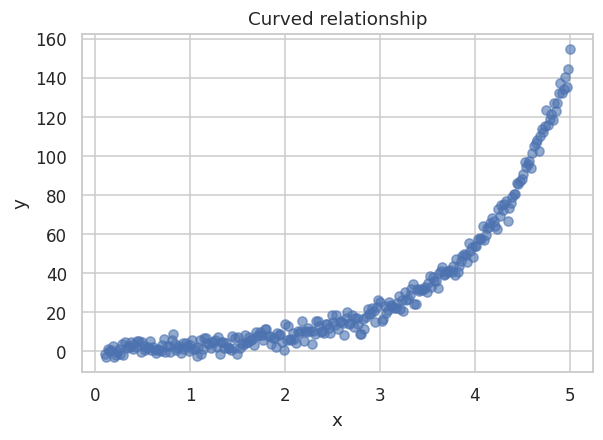


Color intensity vs hue:
{'pearson': -0.5218131932287577, 'spearman': -0.4185217619000421, 'difference': -0.10329143132871565}


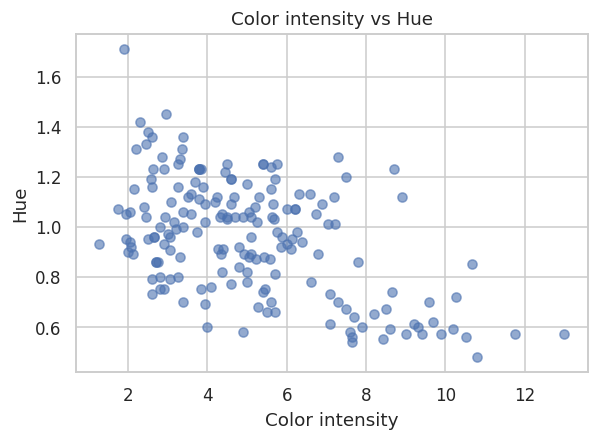

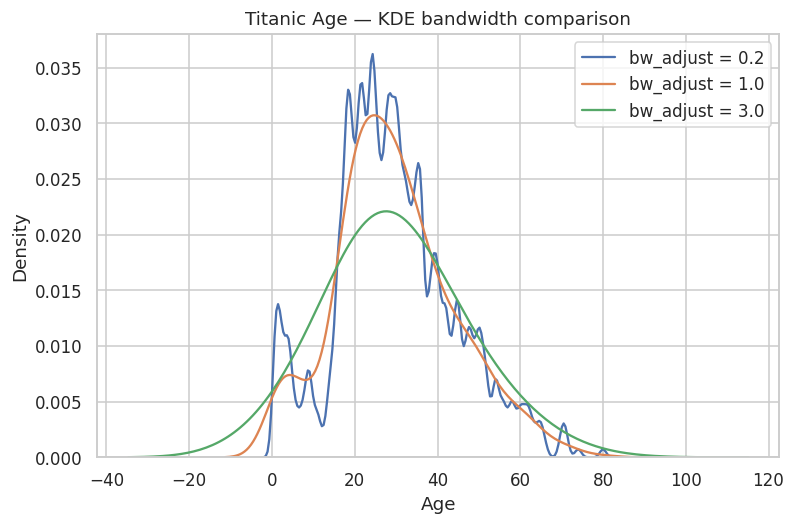

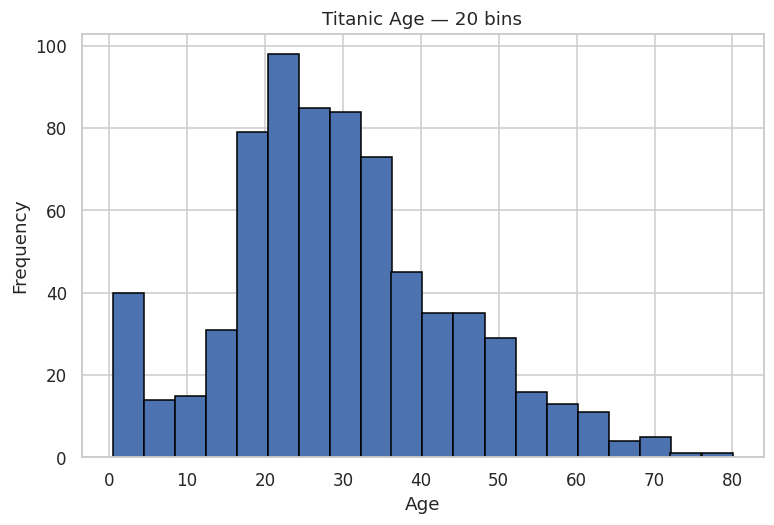

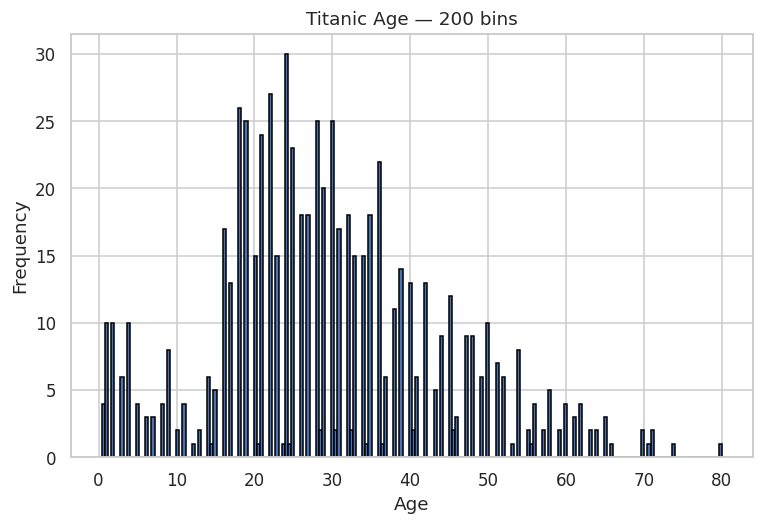

In [18]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt
import seaborn as sns

# (a) Curved pair
print("Curved pair:")
print(_curved)

plt.figure(figsize=(6, 4))
plt.scatter(_curved["x"], _curved["y"], alpha=0.6)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Curved relationship")
plt.show()


# (b) Color intensity vs hue
wine_corr = correlation_pair(wine, "color_intensity", "hue")

print("\nColor intensity vs hue:")
print(wine_corr)

plt.figure(figsize=(6, 4))
plt.scatter(wine["color_intensity"], wine["hue"], alpha=0.6)
plt.xlabel("Color intensity")
plt.ylabel("Hue")
plt.title("Color intensity vs Hue")
plt.show()


# (c) Titanic Age — KDE with different bandwidths
age = titanic["Age"].dropna()

plt.figure(figsize=(8, 5))
sns.kdeplot(age, bw_adjust=0.2, label="bw_adjust = 0.2")
sns.kdeplot(age, bw_adjust=1.0, label="bw_adjust = 1.0")
sns.kdeplot(age, bw_adjust=3.0, label="bw_adjust = 3.0")
plt.xlabel("Age")
plt.ylabel("Density")
plt.title("Titanic Age — KDE bandwidth comparison")
plt.legend()
plt.show()


# Histograms with 20 and 200 bins
plt.figure(figsize=(8, 5))
plt.hist(age, bins=20, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Titanic Age — 20 bins")
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(age, bins=200, edgecolor="black")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("Titanic Age — 200 bins")
plt.show()

**Your answer:**

(c) The number of histogram bins and the KDE bandwidth control the same basic decision: the amount of smoothing used to display the distribution. Using only 20 bins or a large KDE bandwidth produces a smoother representation and can hide real local structure, while using 200 bins or a very small bandwidth produces a much more irregular representation and can create apparent structure from sampling noise. At bw_adjust = 0.2, the Age distribution shows narrow local peaks, including spikes associated with ages being recorded at preferred or rounded values; these should not automatically be interpreted as genuine subgroups of passengers.
Curved pair correlations:
{'pearson': ..., 'spearman': ..., 'difference': ...}

Color intensity vs hue:
{'pearson': ..., 'spearman': ..., 'difference': ...}

## 8. Task 7 — Encoding, and the distances it invents

Applied. Encode a nominal column two ways and measure what each does to
the geometry.

*see Practice 2 §13*

In [19]:
def encoding_distances(series):
    """Compare label encoding against one-hot encoding on a nominal column.

    `series` holds categorical text with no missing values.

    Build both encodings:
      - label:   the categories sorted alphabetically, mapped to 0, 1, 2, ...
      - one-hot: one binary column per category

    Then, for every unordered pair of DISTINCT categories, compute the
    Euclidean distance between their encodings under each scheme.

    Return a DataFrame with one row per pair, indexed by the string
    "A|B" with A and B in alphabetical order, and two columns:
        'label_distance'    |code(A) - code(B)|
        'onehot_distance'   the Euclidean distance between the two one-hot rows

    Rows sorted by index.
    """
    import itertools
    import numpy as np
    import pandas as pd

    # Get categories in alphabetical order
    categories = sorted(series.unique())

    # Label encoding: category -> 0, 1, 2, ...
    label_codes = {
        category: i
        for i, category in enumerate(categories)
    }

    # One-hot encoding
    onehot = pd.get_dummies(
        pd.Series(categories, index=categories)
    ).astype(float)

    rows = {}

    # Every unordered pair of distinct categories
    for a, b in itertools.combinations(categories, 2):

        label_distance = abs(
            label_codes[a] - label_codes[b]
        )

        onehot_distance = float(
            np.linalg.norm(
                onehot.loc[a].to_numpy() -
                onehot.loc[b].to_numpy()
            )
        )

        rows[f"{a}|{b}"] = {
            "label_distance": float(label_distance),
            "onehot_distance": onehot_distance
        }

    result = pd.DataFrame.from_dict(
        rows,
        orient="index"
    )

    return result.sort_index()

In [20]:
_embarked = titanic["Embarked"].fillna("S")
_distances = encoding_distances(_embarked)

assert list(_distances.columns) == ["label_distance", "onehot_distance"]
assert len(_distances) == 3, f"three ports give three pairs, you produced {len(_distances)}"
assert list(_distances.index) == ["C|Q", "C|S", "Q|S"], f"index wrong: {list(_distances.index)}"

# Label encoding invents an ordering: C and S end up twice as far apart.
assert np.isclose(_distances.loc["C|Q", "label_distance"], 1.0)
assert np.isclose(_distances.loc["C|S", "label_distance"], 2.0)
assert np.isclose(_distances.loc["Q|S", "label_distance"], 1.0)

# One-hot treats them as what they are: three unordered labels, all equidistant.
assert np.allclose(_distances["onehot_distance"], np.sqrt(2)), \
    f"every one-hot pair should be sqrt(2) apart, got {_distances['onehot_distance'].tolist()}"
assert _distances["onehot_distance"].nunique() == 1, \
    "one-hot must not distinguish any pair from any other"

print(_distances.round(4))
print("\nTask 7 passed.")

     label_distance  onehot_distance
C|Q          1.0000           1.4142
C|S          2.0000           1.4142
Q|S          1.0000           1.4142

Task 7 passed.


### Question 4 — label against one-hot

**(a)** Under label encoding, C and S are 2 apart while C and Q are 1
apart. Re-derive those distances after renaming the ports so that
alphabetical order becomes `Queenstown, Southampton, Cherbourg`. What
happens to the geometry? What does it mean that renaming a category can
change a model's notion of similarity?

**(b)** `Pclass` also becomes integers 1, 2, 3, and Practice 2 §13.3 says
that is **correct**. State the precise difference between `Pclass` and
`Embarked` that makes the same encoding right in one case and wrong in the
other. Your answer must not mention the data type.

**(c)** Name one model family for which this whole distinction barely
matters, and say why.

In [21]:
# Space for the code that supports your answer.
# Question 4(a): distances after renaming/reordering categories

ports = ["Queenstown", "Southampton", "Cherbourg"]

codes = {port: i for i, port in enumerate(ports)}

print("Label codes:", codes)
print("Q-S distance:", abs(codes["Queenstown"] - codes["Southampton"]))
print("Q-C distance:", abs(codes["Queenstown"] - codes["Cherbourg"]))
print("S-C distance:", abs(codes["Southampton"] - codes["Cherbourg"]))

Label codes: {'Queenstown': 0, 'Southampton': 1, 'Cherbourg': 2}
Q-S distance: 1
Q-C distance: 2
S-C distance: 1


**Your answer:**

(a) After renaming the ports so that the order is Queenstown, Southampton, Cherbourg, label encoding assigns them 0, 1, and 2. The distances therefore become Q-S = 1, S-C = 1, and Q-C = 2. The geometry has changed even though the underlying categories have not changed: previously C and S were 2 apart and C and Q were 1 apart, but now C and Q are 2 apart. This shows that label encoding creates an artificial notion of distance and similarity that depends on the category names and their ordering rather than on a real relationship between the ports. A model that uses these numerical distances may therefore treat categories as more or less similar simply because they were renamed.

(b) Pclass has an intrinsic ordered relationship: class 1, class 2, and class 3 represent successive levels, so encoding them as 1, 2, and 3 preserves meaningful order. Embarked has no intrinsic ordered relationship between its possible values, so assigning consecutive integers creates an order and numerical distances that have no real meaning. This is why integer encoding is appropriate for Pclass but inappropriate for Embarked.

(c) Tree-based models, such as decision trees or random forests, are a model family for which this distinction often matters much less. They make decisions by splitting values into regions rather than directly interpreting Euclidean distances between encoded observations, although the encoding can still affect which category groupings are easy for a particular tree to represent.

## 9. Task 8 — Scale without leaking

Applied. Split, then fit the scaler on the training half only.

*see Practice 2 §14.3*

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def split_and_scale(X, y, test_size=0.3, random_state=SEED):
    """Split into train and test, then standardise WITHOUT leakage.

    Split first with train_test_split, stratifying on y and using the
    given random_state. Then fit a StandardScaler on the TRAINING features
    only, and use it to transform both halves.

    Return a dict with exactly these five keys:
        'X_train', 'X_test'   the scaled feature arrays
        'y_train', 'y_test'   the labels
        'scaler'              the fitted StandardScaler
    """
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return {
        "X_train": X_train_scaled,
        "X_test": X_test_scaled,
        "y_train": y_train,
        "y_test": y_test,
        "scaler": scaler
    }

In [23]:
_features = [c for c in wine.columns if c != "target"]
_split = split_and_scale(wine[_features].values, wine["target"].values)

assert set(_split) == {"X_train", "X_test", "y_train", "y_test", "scaler"}
assert _split["X_train"].shape[0] + _split["X_test"].shape[0] == len(wine)
assert _split["X_train"].shape[1] == 13

# The TRAINING half must be exactly standardised...
assert np.allclose(_split["X_train"].mean(axis=0), 0.0, atol=1e-10), \
    "the training set should have mean 0 after scaling"
assert np.allclose(_split["X_train"].std(axis=0), 1.0, atol=1e-10), \
    "the training set should have unit variance after scaling"

# ...and the TEST half must NOT be, because its statistics were never used.
assert not np.allclose(_split["X_test"].mean(axis=0), 0.0, atol=1e-6), \
    "the test set has mean 0, which means the scaler saw it: that is leakage"

# The scaler must have been fitted on the training rows only.
_leaky = StandardScaler().fit(wine[_features].values)
assert not np.allclose(_split["scaler"].mean_, _leaky.mean_), \
    "your scaler's means match a scaler fitted on the whole dataset"

# stratify= must preserve the class balance
_train_balance = np.bincount(_split["y_train"]) / len(_split["y_train"])
_full_balance = np.bincount(wine["target"].values) / len(wine)
assert np.allclose(_train_balance, _full_balance, atol=0.02), \
    "the class balance was not preserved; did you pass stratify=y?"

print("train", _split["X_train"].shape, " test", _split["X_test"].shape)
print("train mean (first 3 features):", _split["X_train"].mean(axis=0)[:3].round(10))
print("test  mean (first 3 features):", _split["X_test"].mean(axis=0)[:3].round(4), " <- not zero, correctly")
print("\nTask 8 passed.")

train (124, 13)  test (54, 13)
train mean (first 3 features): [ 0. -0. -0.]
test  mean (first 3 features): [-0.0324  0.0259 -0.0291]  <- not zero, correctly

Task 8 passed.


### Question 5 — scaling choices

**(a)** Repeat Task 8 with `MinMaxScaler` instead. Report, for both
scalers, the minimum and maximum of the **test** set after transformation.
Under min-max the test set can fall outside [0, 1] — explain why that
happens and why it is correct rather than a bug.

**(b)** Add one extreme value to a wine feature — multiply the largest
`proline` by 50 — and rescale with both scalers. Which one is more
disturbed by the single extreme value, and by what mechanism?

**(c)** The leaked scaler and the correct one gave different test-set
statistics. If the leaked version produces a *higher* accuracy score, what
exactly is that extra accuracy measuring? Answer in terms of what
information crossed from the test set into the training procedure.

In [24]:
# Space for the code that supports your answer.
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

# Prepare wine data
features = [c for c in wine.columns if c != "target"]
X = wine[features]
y = wine["target"]

# Use exactly the same train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=SEED,
    stratify=y
)

# (a) StandardScaler
standard_scaler = StandardScaler()
X_train_std = standard_scaler.fit_transform(X_train)
X_test_std = standard_scaler.transform(X_test)

# MinMaxScaler
minmax_scaler = MinMaxScaler()
X_train_mm = minmax_scaler.fit_transform(X_train)
X_test_mm = minmax_scaler.transform(X_test)

print("(a) Test-set ranges")
print(
    "StandardScaler:",
    "min =", X_test_std.min(),
    "max =", X_test_std.max()
)

print(
    "MinMaxScaler:",
    "min =", X_test_mm.min(),
    "max =", X_test_mm.max()
)


# (b) Add an extreme value to proline
X_extreme = X.copy()

proline_idx = X_extreme["proline"].idxmax()
X_extreme.loc[proline_idx, "proline"] *= 50

# Scale original and modified data for comparison
std_original = StandardScaler().fit_transform(X)
std_extreme = StandardScaler().fit_transform(X_extreme)

mm_original = MinMaxScaler().fit_transform(X)
mm_extreme = MinMaxScaler().fit_transform(X_extreme)

proline_col = features.index("proline")

print("\n(b) Proline after adding extreme value")

print(
    "StandardScaler range:",
    std_extreme[:, proline_col].min(),
    "to",
    std_extreme[:, proline_col].max()
)

print(
    "MinMaxScaler range:",
    mm_extreme[:, proline_col].min(),
    "to",
    mm_extreme[:, proline_col].max()
)

print(
    "Original proline max:",
    X["proline"].max()
)

print(
    "Extreme proline max:",
    X_extreme["proline"].max()
)

(a) Test-set ranges
StandardScaler: min = -2.5320938741135497 max = 4.757209616392294
MinMaxScaler: min = -0.04363636363636364 max = 1.1358024691358026

(b) Proline after adding extreme value
StandardScaler range: -0.14948605565335288 to 13.288069882838421
MinMaxScaler range: 0.0 to 1.0000000000000002
Original proline max: 1680.0
Extreme proline max: 84000.0


**Your answer:**

(a) With StandardScaler, the transformed test-set values range from approximately -2.5321 to 4.7572. With MinMaxScaler, they range from approximately -0.0436 to 1.1358. The MinMaxScaler is fitted only on the training set, so it maps the training minimum and maximum to 0 and 1. If the test set contains values smaller than the training minimum or larger than the training maximum, their transformed values can therefore fall below 0 or above 1. This is correct behaviour and not a bug, because using the test-set minimum and maximum during fitting would cause data leakage.

(b) After multiplying the largest proline value by 50, its maximum changes from 1680 to 84000. MinMaxScaler is more strongly disturbed by this single extreme value because its transformation depends directly on the minimum and maximum. The extreme maximum greatly increases the range and compresses almost all ordinary proline observations into a very small part of the [0, 1] interval. StandardScaler is also affected because the extreme value changes the mean and standard deviation, but its mechanism is based on centering by the mean and scaling by the standard deviation rather than directly fixing the observed extremes to 0 and 1.

(c) If the leaked scaler gives a higher test accuracy, that extra accuracy is not an unbiased estimate of performance on unseen data. Information about the test-set distribution crossed into the training procedure through the scaling statistics: for StandardScaler this means the test values influenced the estimated means and standard deviations, while for MinMaxScaler they influenced the minima and maxima. The model was therefore trained on features whose transformation already contained information about the supposedly unseen test set, making the resulting accuracy optimistically biased.(a) With StandardScaler, the transformed test-set values range from approximately -2.5321 to 4.7572. With MinMaxScaler, they range from approximately -0.0436 to 1.1358. The MinMaxScaler is fitted only on the training set, so it maps the training minimum and maximum to 0 and 1. If the test set contains values smaller than the training minimum or larger than the training maximum, their transformed values can therefore fall below 0 or above 1. This is correct behaviour and not a bug, because using the test-set minimum and maximum during fitting would cause data leakage.

(b) After multiplying the largest proline value by 50, its maximum changes from 1680 to 84000. MinMaxScaler is more strongly disturbed by this single extreme value because its transformation depends directly on the minimum and maximum. The extreme maximum greatly increases the range and compresses almost all ordinary proline observations into a very small part of the [0, 1] interval. StandardScaler is also affected because the extreme value changes the mean and standard deviation, but its mechanism is based on centering by the mean and scaling by the standard deviation rather than directly fixing the observed extremes to 0 and 1.

(c) If the leaked scaler gives a higher test accuracy, that extra accuracy is not an unbiased estimate of performance on unseen data. Information about the test-set distribution crossed into the training procedure through the scaling statistics: for StandardScaler this means the test values influenced the estimated means and standard deviations, while for MinMaxScaler they influenced the minima and maxima. The model was therefore trained on features whose transformation already contained information about the supposedly unseen test set, making the resulting accuracy optimistically biased.

## 10. Task 9 — How many principal components

Applied.

*see Practice 2 §15.2 and §15.3*

In [29]:
from sklearn.decomposition import PCA

def components_for_variance(X, thresholds=(0.5, 0.8, 0.95, 0.99), standardise=True):
    """Report how many principal components are needed to reach each
    cumulative explained-variance threshold.

    If `standardise` is True, fit a StandardScaler on X and transform it
    before running PCA. Otherwise use X as given.

    Fit PCA with all components and random_state=SEED.

    Return a dict with two keys:
        'cumulative'  the cumulative explained variance ratio, a 1-D array
        'needed'      a dict mapping each threshold to the SMALLEST number
                      of components whose cumulative variance is >= it,
                      as an int (1 means the first component alone suffices)
    """
    if standardise:
        scaler = StandardScaler()
        X_used = scaler.fit_transform(X)
    else:
        X_used = X

    pca = PCA(random_state=SEED)
    pca.fit(X_used)

    cumulative = np.cumsum(pca.explained_variance_ratio_)

    needed = {}

    for threshold in thresholds:
        needed[threshold] = int(
            np.argmax(cumulative >= threshold) + 1
        )

    return {
        "cumulative": cumulative,
        "needed": needed
    }

In [30]:
_X_wine = wine[_features].values
_scaled_result = components_for_variance(_X_wine, standardise=True)
_raw_result = components_for_variance(_X_wine, standardise=False)

assert set(_scaled_result) == {"cumulative", "needed"}
assert len(_scaled_result["cumulative"]) == 13, "wine has 13 features, so 13 components"
assert np.isclose(_scaled_result["cumulative"][-1], 1.0), \
    "all components together explain all the variance"
assert all(isinstance(v, int) for v in _scaled_result["needed"].values())

# Monotonic: a higher threshold never needs fewer components.
_counts = [_scaled_result["needed"][t] for t in (0.5, 0.8, 0.95, 0.99)]
assert _counts == sorted(_counts), f"counts must be non-decreasing: {_counts}"

# Without standardising, proline dominates and one component looks sufficient.
assert _raw_result["needed"][0.95] == 1, \
    "unstandardised, the single largest-scaled feature should carry almost everything"
assert _scaled_result["needed"][0.95] > _raw_result["needed"][0.95], \
    "standardising should require more components to reach 95%"

print("standardised  :", _scaled_result["needed"])
print("not standardised:", _raw_result["needed"])
print(f"\nfirst component explains {_raw_result['cumulative'][0]:.2%} unstandardised, "
      f"{_scaled_result['cumulative'][0]:.2%} standardised")
print("\nTask 9 passed.")

standardised  : {0.5: 2, 0.8: 5, 0.95: 10, 0.99: 12}
not standardised: {0.5: 1, 0.8: 1, 0.95: 1, 0.99: 1}

first component explains 99.81% unstandardised, 36.20% standardised

Task 9 passed.


### Question 6 — components, and the cost of keeping fewer

**(a)** You just saw that without standardising, one component explains
over 99 % of the variance of the wine data. Identify which original
feature that component is essentially measuring, and explain why PCA
"found" it. What does this tell you about running PCA on columns in
different units?

**(b)** Plot the cumulative curve for the standardised wine data. Choosing
95 % gives you one number of components, 80 % gives another. Neither
threshold is derived from anything. Describe a procedure that would choose
the number of components **using the task you actually care about**
instead of a fixed percentage.

**(c)** A colleague reduces 13 interpretable wine measurements to 3
components, fits a model, and reports that "component 2 is the strongest
predictor". What can and cannot be said to a winemaker on the basis of
that sentence?

(a) PCA without standardisation
Variance explained by PC1: 0.9980912304918974
Largest loading in PC1:
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047
color_intensity     0.0023
alcohol             0.0017
dtype: float64

(b) Standardised PCA
Components for 80%: 5
Components for 95%: 10

Cumulative explained variance:
1 components: 0.3620
2 components: 0.5541
3 components: 0.6653
4 components: 0.7360
5 components: 0.8016
6 components: 0.8510
7 components: 0.8934
8 components: 0.9202
9 components: 0.9424
10 components: 0.9617
11 components: 0.9791
12 components: 0.9920
13 components: 1.0000


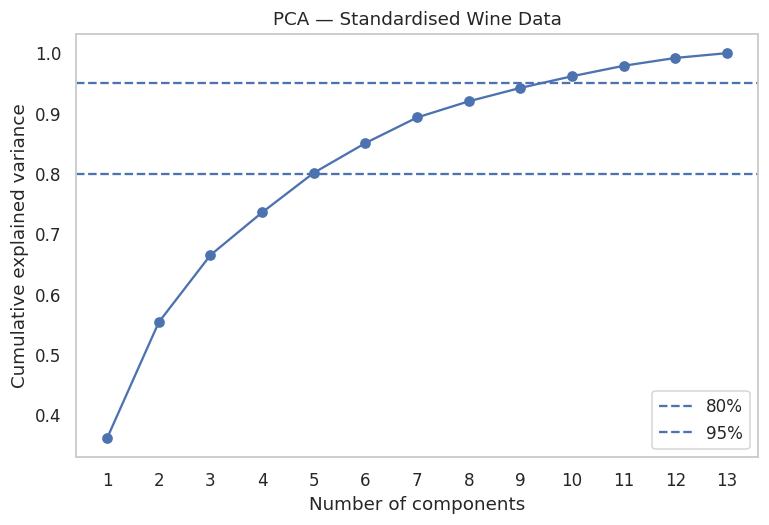

In [31]:
# Space for the code that supports your answer.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Wine features
features = [c for c in wine.columns if c != "target"]
X = wine[features]

# (a) PCA WITHOUT standardisation
pca_raw = PCA()
pca_raw.fit(X)

first_component = pd.Series(
    np.abs(pca_raw.components_[0]),
    index=features
).sort_values(ascending=False)

print("(a) PCA without standardisation")
print("Variance explained by PC1:",
      pca_raw.explained_variance_ratio_[0])
print("Largest loading in PC1:")
print(first_component.head())


# (b) PCA WITH standardisation
X_scaled = StandardScaler().fit_transform(X)

pca_scaled = PCA()
pca_scaled.fit(X_scaled)

cumulative = np.cumsum(
    pca_scaled.explained_variance_ratio_
)

n_80 = np.argmax(cumulative >= 0.80) + 1
n_95 = np.argmax(cumulative >= 0.95) + 1

print("\n(b) Standardised PCA")
print("Components for 80%:", n_80)
print("Components for 95%:", n_95)

print("\nCumulative explained variance:")
for i, value in enumerate(cumulative, start=1):
    print(f"{i} components: {value:.4f}")

# Cumulative explained-variance plot
plt.figure(figsize=(8, 5))
plt.plot(
    range(1, len(cumulative) + 1),
    cumulative,
    marker="o"
)

plt.axhline(0.80, linestyle="--", label="80%")
plt.axhline(0.95, linestyle="--", label="95%")

plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA — Standardised Wine Data")
plt.xticks(range(1, len(cumulative) + 1))
plt.legend()
plt.grid()
plt.show()

**Your answer:**

(a) Without standardisation, the first principal component explains about 99.81% of the total variance and is essentially measuring proline. Its loading on PC1 is about 0.9998, far larger than the loadings of the other features. PCA finds this because proline is measured on a much larger numerical scale and therefore contributes much more raw variance than the other variables. This shows that PCA on variables measured in different units can be dominated by scale rather than by the underlying multivariate structure, so standardisation is important when the units and scales are not directly comparable.

(b) For the standardised wine data, 5 principal components are required to explain at least 80% of the variance (about 80.16%), while 10 components are required to explain at least 95% (about 96.17%). However, neither 80% nor 95% is a universally correct threshold. A better procedure would be to treat the number of components as a model-selection choice: evaluate different numbers of components using cross-validation on the downstream task, such as classification, and choose the smallest number that achieves satisfactory out-of-sample performance. This selects the dimensionality according to the task we actually care about rather than an arbitrary explained-variance percentage.

(c) Saying that "component 2 is the strongest predictor" means that the particular linear combination of the original measurements represented by PC2 was especially useful to the fitted predictive model. It does not mean that there is a single original wine measurement called "component 2", nor does it show that one specific chemical property is the strongest cause of the outcome. To give the result a meaningful interpretation to a winemaker, we would need to examine the loadings of PC2 to determine which original measurements contribute to it and in which directions. Even then, predictive importance should not automatically be interpreted as a causal relationship.

## 11. Task 10 — A two-dimensional projection of 784 dimensions

Applied, and the last mechanical task. This is the projection Lesson 3
clusters.

`mnist_sample.csv` is 1500 handwritten digits, each a 28 by 28 image
flattened into 784 pixel columns. Reducing with PCA before running t-SNE
is standard practice: it removes noise and makes t-SNE several times
faster.

*see Practice 2 §15.2, §15.5 and §15.6*

In [32]:
from sklearn.manifold import TSNE

def project_two_ways(X, perplexity, seed, n_pca=50):
    """Project a high-dimensional array to 2-D, twice, and compare.

    Steps, in this order:
      1. standardise X with StandardScaler
      2. PCA to `n_pca` components, random_state=seed  -> the t-SNE input
      3. t-SNE from that reduction to 2 components, with the given
         `perplexity`, random_state=seed and init='pca'

    Separately, take the first TWO components of a PCA on the standardised
    data, so the linear and nonlinear projections can be compared.

    Return a dict with exactly these four keys:
        'pca_2d'        shape (n_samples, 2), the linear projection
        'tsne_2d'       shape (n_samples, 2), the nonlinear projection
        'explained_2d'  the fraction of variance the two PCA components
                        carry, a float between 0 and 1
        'reduced'       shape (n_samples, n_pca), the PCA input to t-SNE
    """
        # 1. Standardise the data
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 2. PCA reduction for t-SNE
    pca = PCA(n_components=n_pca, random_state=seed)
    reduced = pca.fit_transform(X_scaled)

    # 3. t-SNE projection to 2 dimensions
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        random_state=seed,
        init="pca"
    )
    tsne_2d = tsne.fit_transform(reduced)

    # 4. Separate linear PCA projection to 2 dimensions
    pca_2 = PCA(n_components=2, random_state=seed)
    pca_2d = pca_2.fit_transform(X_scaled)

    # Fraction of variance explained by the first two PCs
    explained_2d = float(
        pca_2.explained_variance_ratio_.sum()
    )

    return {
        "pca_2d": pca_2d,
        "tsne_2d": tsne_2d,
        "explained_2d": explained_2d,
        "reduced": reduced
    }

In [33]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

pixels (1500, 784)  labels (1500,)
one row reshaped back into an image: (28, 28)


In [36]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
mnist = pd.read_csv("../datasets/mnist_sample.csv")
digit_labels = mnist["label"].values
pixels = mnist.drop(columns="label").values

print("pixels", pixels.shape, " labels", digit_labels.shape)
print("one row reshaped back into an image:", pixels[0].reshape(28, 28).shape)

# A 300-row subset keeps the assert cell below to a few seconds.
_small = pixels[:300]
_projection = project_two_ways(_small, perplexity=30, seed=SEED)

FileNotFoundError: [Errno 2] No such file or directory: '../datasets/mnist_sample.csv'

In [37]:
assert set(_projection) == {"pca_2d", "tsne_2d", "explained_2d", "reduced"}
assert _projection["pca_2d"].shape == (300, 2), f"pca_2d shape {_projection['pca_2d'].shape}"
assert _projection["tsne_2d"].shape == (300, 2), f"tsne_2d shape {_projection['tsne_2d'].shape}"
assert _projection["reduced"].shape == (300, 50), f"reduced shape {_projection['reduced'].shape}"
assert 0.0 < _projection["explained_2d"] < 1.0

# Two linear components cannot carry much of 784 dimensions.
assert _projection["explained_2d"] < 0.30, \
    f"two components explaining {_projection['explained_2d']:.1%} of 784 dimensions looks wrong"

# Seeded, so the same call reproduces exactly...
_again = project_two_ways(_small, perplexity=30, seed=SEED)
assert np.allclose(_projection["tsne_2d"], _again["tsne_2d"]), \
    "same seed must give the same embedding; did you pass random_state?"

# ...and a different seed does not.
_other = project_two_ways(_small, perplexity=30, seed=SEED + 1)
assert not np.allclose(_projection["tsne_2d"], _other["tsne_2d"]), \
    "a different seed should give a different embedding"

# t-SNE is not PCA: the two projections must differ.
assert not np.allclose(_projection["pca_2d"], _projection["tsne_2d"])

# t-SNE places THESE points and has no rule for placing new ones. Ask the
# class, not an instance -- there is nothing to seed and nothing to fit.
assert not hasattr(TSNE, "transform"), \
    "t-SNE has no transform, which is why it cannot be a preprocessing step"
assert hasattr(PCA, "transform"), "PCA does have one, and that is the difference"

print(f"two PCA components carry {_projection['explained_2d']:.2%} of the variance")
print("Task 10 passed.")

two PCA components carry 13.58% of the variance
Task 10 passed.


### Question 7 — perplexity, and the seed

Using the **full** 1500 rows this time, produce three t-SNE projections at
`perplexity` = 5, 30 and 50, all with the same seed, and draw them side by
side coloured by `digit_labels`. Then produce two more at `perplexity=30`
with two **different** seeds.

**(a)** Describe how the picture changes across the three perplexities.
Roughly what is perplexity controlling — say it in terms of how many
neighbours each point is trying to stay close to. Which extreme shatters
the classes and which merges them?

**(b)** Your two different-seed runs at the same perplexity also differ.
Explain why t-SNE is seed-dependent at all, and what that means for a
figure published without a stated `random_state`.

**(c)** Compare any of your t-SNE panels with the `pca_2d` projection. The
t-SNE picture separates the digits far better. State **three things you
still cannot conclude** from it — refer to Practice 2 §15.7 — and say which
of the two projections you would use as input to a clustering algorithm,
and why.

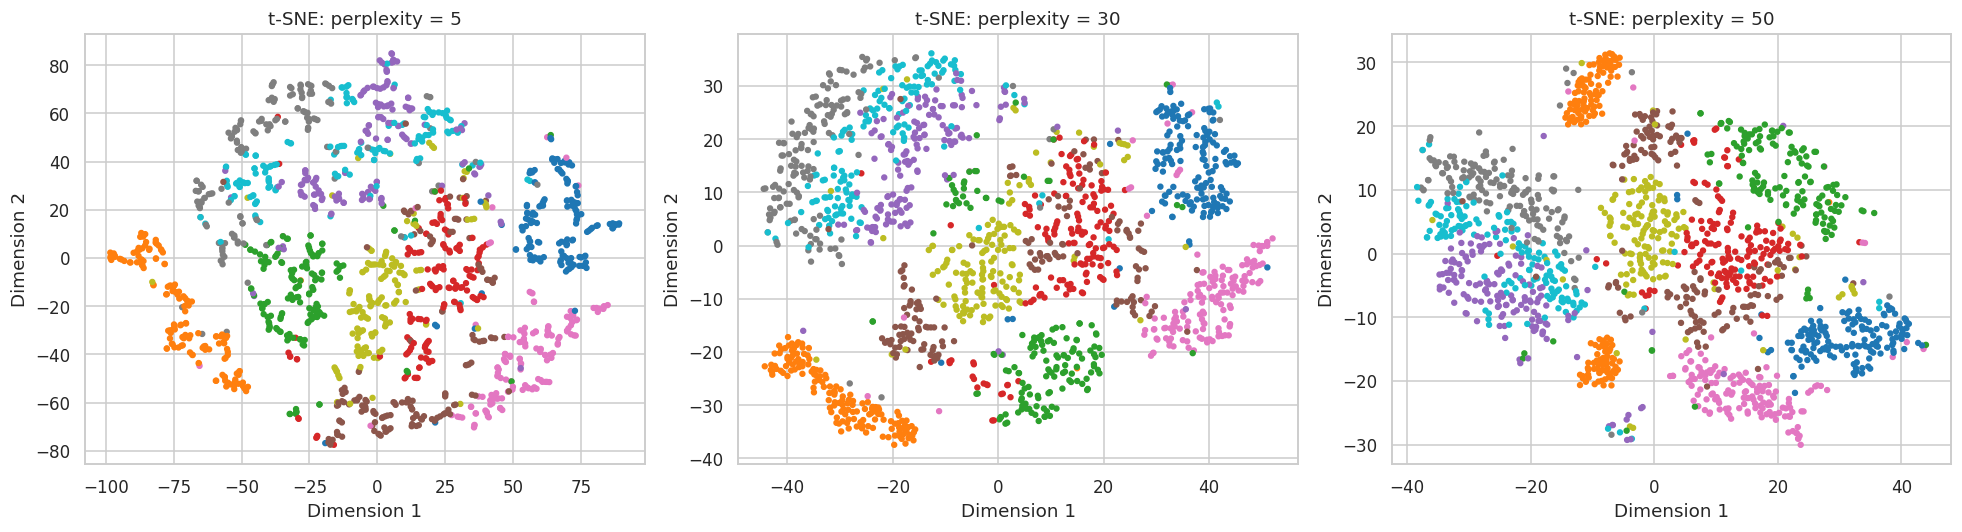

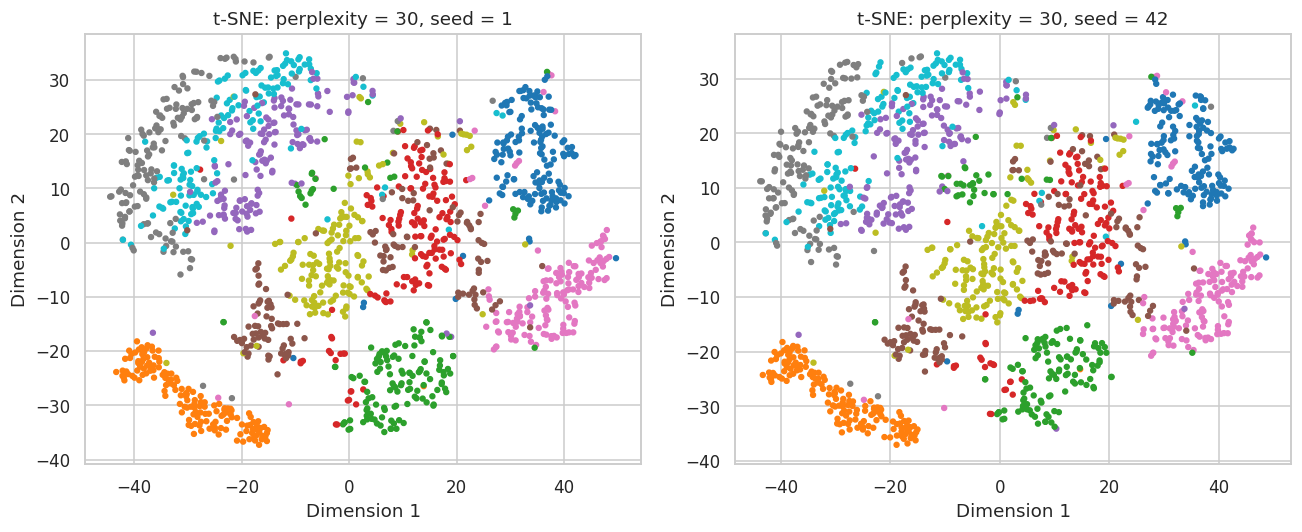

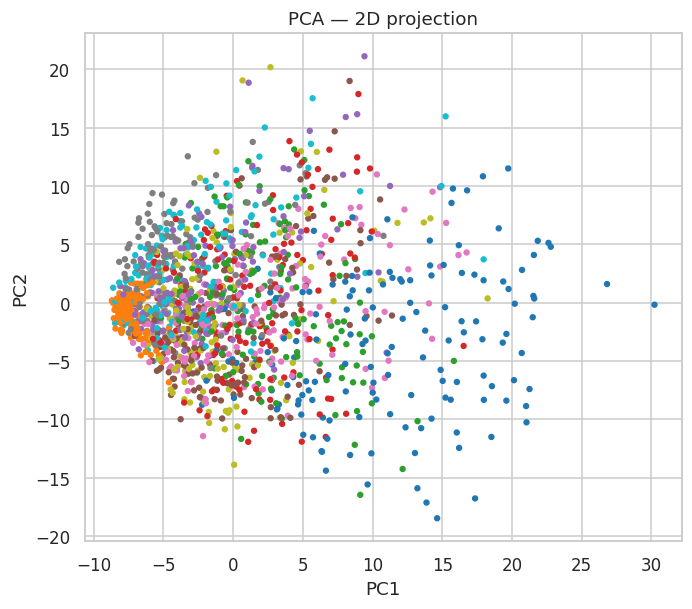

In [38]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# Full MNIST sample: all 1500 rows
# Three perplexities with the same seed
proj_p5 = project_two_ways(
    pixels, perplexity=5, seed=SEED
)

proj_p30 = project_two_ways(
    pixels, perplexity=30, seed=SEED
)

proj_p50 = project_two_ways(
    pixels, perplexity=50, seed=SEED
)

# Plot the three perplexities side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, proj, perp in zip(
    axes,
    [proj_p5, proj_p30, proj_p50],
    [5, 30, 50]
):
    ax.scatter(
        proj["tsne_2d"][:, 0],
        proj["tsne_2d"][:, 1],
        c=digit_labels,
        cmap="tab10",
        s=10
    )
    ax.set_title(f"t-SNE: perplexity = {perp}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()


# Same perplexity, two different seeds
proj_seed1 = project_two_ways(
    pixels, perplexity=30, seed=1
)

proj_seed2 = project_two_ways(
    pixels, perplexity=30, seed=42
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, proj, seed in zip(
    axes,
    [proj_seed1, proj_seed2],
    [1, 42]
):
    ax.scatter(
        proj["tsne_2d"][:, 0],
        proj["tsne_2d"][:, 1],
        c=digit_labels,
        cmap="tab10",
        s=10
    )
    ax.set_title(f"t-SNE: perplexity = 30, seed = {seed}")
    ax.set_xlabel("Dimension 1")
    ax.set_ylabel("Dimension 2")

plt.tight_layout()
plt.show()


# PCA 2-D projection for comparison
pca_2d = proj_p30["pca_2d"]

plt.figure(figsize=(7, 6))
plt.scatter(
    pca_2d[:, 0],
    pca_2d[:, 1],
    c=digit_labels,
    cmap="tab10",
    s=10
)

plt.title("PCA — 2D projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

**Your answer:**

(a) The t-SNE picture changes noticeably as perplexity changes. Perplexity roughly controls the number of neighbouring points that each observation tries to preserve as close neighbours: a low value such as 5 emphasizes very local structure, while larger values such as 30 or 50 consider broader neighbourhoods. At perplexity = 5 the digit classes are more fragmented into small local groups, whereas at higher perplexity some groups become more compact but nearby structures can also be merged. Thus, very low perplexity tends to shatter classes, while very high perplexity can merge structures that are distinct at a more local scale.

(b) The two runs at perplexity = 30 with different seeds can produce different layouts because t-SNE is a nonlinear optimization procedure whose result depends on its initialization and optimization path. Different random seeds can therefore lead to different two-dimensional arrangements even when the original data and perplexity are unchanged. A published t-SNE figure without a stated random_state is not completely reproducible, and apparent global positions or orientations of clusters should not be treated as uniquely determined by the data.

(c) The t-SNE projections separate many of the digit classes much more clearly than the two-dimensional PCA projection, where the coloured classes overlap strongly. However, three conclusions still cannot safely be made from t-SNE: distances between separate clusters should not be interpreted as faithful global distances in the original 784-dimensional space; apparent cluster sizes or densities should not be interpreted directly as the true sizes or densities of the original groups; and visible gaps or isolated clusters do not by themselves prove that the data contain objectively distinct natural classes. For clustering, I would use the PCA-reduced representation rather than the two-dimensional t-SNE coordinates, because PCA provides a more stable representation and preserves broader variance structure, while t-SNE is primarily designed for visualization and can distort global geometry.

## 12. Task 11 — A figure that answers a stated question

Applied. The question: **does the daily demand profile for bicycles differ
between working days and non-working days, and how does weather change
it?**

*see Practice 2 §8.4, §9 and §10*

In [39]:
def demand_profile_figure(bikes_frame):
    """Draw a two-panel figure answering the question above. Return (fig, axes).

    Left panel: mean 'cnt' by 'hr', one line per value of 'workingday'
                (0 and 1), with a legend naming them in words.
    Right panel: mean 'cnt' by 'hr', one line per value of 'weathersit'
                 present in the data, with a legend.

    Both panels need an x label, a y label and a title. The figure needs a
    suptitle. Use the object-oriented interface.
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left panel: working vs non-working days
    working_labels = {
        0: "Non-working day",
        1: "Working day"
    }

    for value in sorted(bikes_frame["workingday"].dropna().unique()):
        data = (
            bikes_frame[bikes_frame["workingday"] == value]
            .groupby("hr")["cnt"]
            .mean()
        )

        axes[0].plot(
            data.index,
            data.values,
            marker="o",
            label=working_labels[value]
        )

    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Mean bicycle demand")
    axes[0].set_title("Daily demand: working vs non-working days")
    axes[0].legend()

    # Right panel: weather situation
    for value in sorted(bikes_frame["weathersit"].dropna().unique()):
        data = (
            bikes_frame[bikes_frame["weathersit"] == value]
            .groupby("hr")["cnt"]
            .mean()
        )

        axes[1].plot(
            data.index,
            data.values,
            marker="o",
            label=f"Weather {value}"
        )

    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("Mean bicycle demand")
    axes[1].set_title("Daily demand by weather")
    axes[1].legend()

    fig.suptitle(
        "Bicycle demand profiles by working day and weather"
    )

    fig.tight_layout()

    return fig, axes

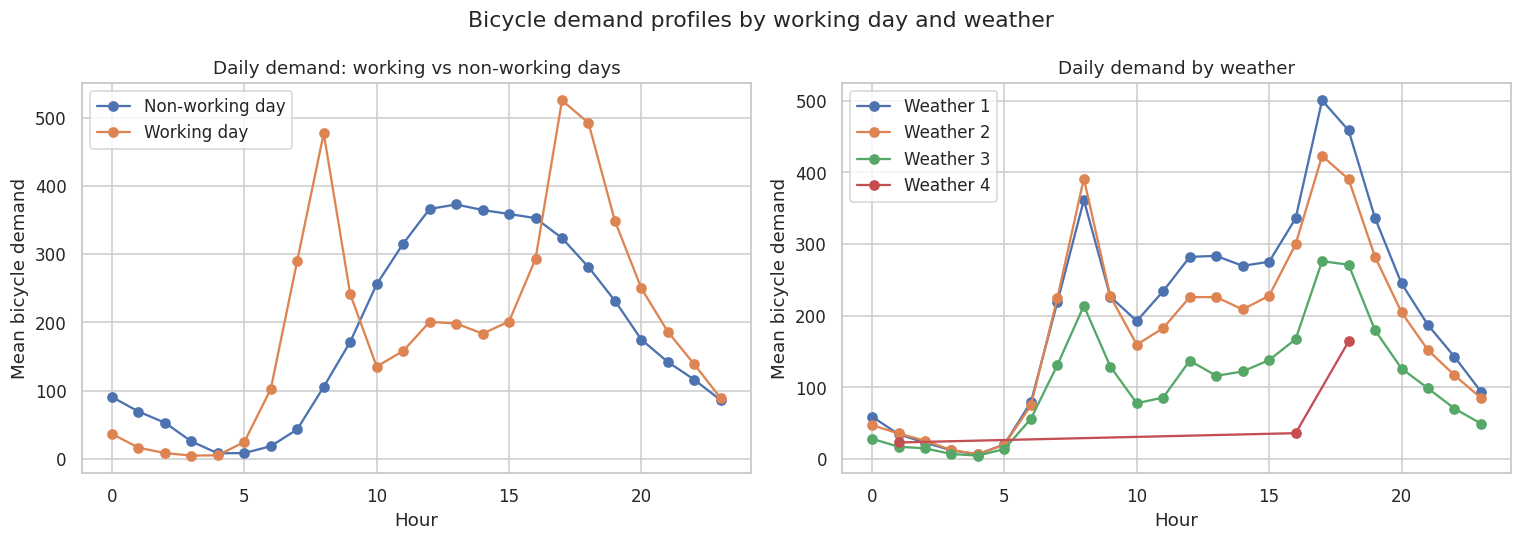

Task 11 passed.


In [40]:
_fig, _axes = demand_profile_figure(bikes)

assert len(_axes) == 2, f"expected two panels, got {len(_axes)}"
for _i, _ax in enumerate(_axes):
    assert _ax.get_xlabel(), f"panel {_i} has no x label"
    assert _ax.get_ylabel(), f"panel {_i} has no y label"
    assert _ax.get_title(), f"panel {_i} has no title"
    assert _ax.get_legend() is not None, f"panel {_i} has no legend"
    assert len(_ax.lines) >= 2, f"panel {_i} should have at least two lines"
assert _fig._suptitle is not None and _fig._suptitle.get_text(), "the figure has no suptitle"
assert len(_axes[0].lines) == 2, "the left panel compares exactly two groups"

plt.show()
print("Task 11 passed.")

### Question 8 — pooling and conditioning

**(a)** Draw the *pooled* profile as well: mean `cnt` by `hr` with no
conditioning. Compare it with your two-line left panel. Describe a
statement about commuter behaviour that the pooled figure would support
and that is false for both of the underlying groups.

**(b)** This is the same phenomenon as Practice 2 §12. Name it, and state
the general rule it implies about reporting an aggregate.

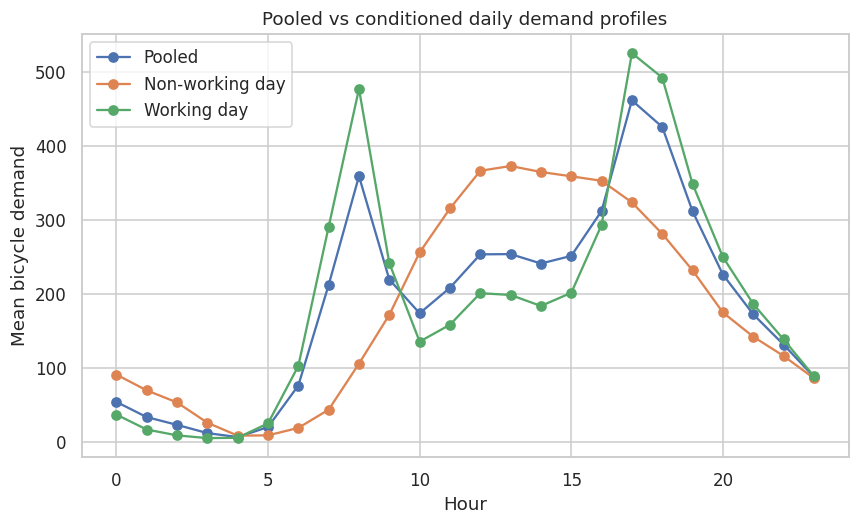

In [41]:
# Space for the code that supports your answer.
import matplotlib.pyplot as plt

# Pooled profile: mean demand by hour without conditioning
pooled = bikes.groupby("hr")["cnt"].mean()

# Profiles for working and non-working days
non_working = (
    bikes[bikes["workingday"] == 0]
    .groupby("hr")["cnt"]
    .mean()
)

working = (
    bikes[bikes["workingday"] == 1]
    .groupby("hr")["cnt"]
    .mean()
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(pooled.index, pooled.values,
        marker="o", label="Pooled")

ax.plot(non_working.index, non_working.values,
        marker="o", label="Non-working day")

ax.plot(working.index, working.values,
        marker="o", label="Working day")

ax.set_xlabel("Hour")
ax.set_ylabel("Mean bicycle demand")
ax.set_title("Pooled vs conditioned daily demand profiles")
ax.legend()

plt.show()

**Your answer:**

(a) The pooled profile hides the important difference between working and non-working days. It could suggest that a typical day has two moderate commuter peaks, one in the morning and another in the evening. However, this is not true for both underlying groups: working days have strong and sharp peaks around 8:00 and 17:00–18:00, while non-working days have no comparable morning rush-hour peak and instead show a broad increase in demand during the middle of the day. Therefore, the pooled profile combines two different patterns and does not accurately represent either group.

(b) This is an example of Simpson's paradox, or more generally an aggregation effect. A pattern observed in pooled data can change or become misleading after conditioning on an important grouping variable. Therefore, before interpreting an aggregate, relevant subgroups should be examined separately to check whether the aggregate hides different underlying relationships.

## 13. Task 12 — Open-ended

No assert. Marked on the written analysis.

`bike_sharing_hourly.csv` is documented in `practice/datasets/README.md`.
Read that table first: four of the columns are integer-coded categories,
four are physical measurements that the publisher divided by a constant,
one is a date stored as text, and `casual + registered` equals `cnt`
exactly.

**Produce a short data-quality and structure report on this table.** Cover
at least:

1. **Types.** Which columns does pandas infer wrongly, in the sense that
   the inferred type permits an operation that is meaningless? Fix them
   and show one operation that becomes an error after your fix.
2. **Units.** Restore the four normalised columns to physical units and
   sanity-check the resulting ranges against what you know about
   Washington D.C. Report anything that looks wrong.
3. **The date.** Parse `dteday`. Confirm the series is complete: is there
   one row for every hour of every day in the range? If rows are missing,
   how many, and does their absence look random?
4. **A correlation you should not compute.** Produce the correlation
   matrix of the numeric columns, then identify at least two entries in it
   that are meaningless or misleading, and say why. At least one of your
   examples must be about an integer-coded category.
5. **Leakage.** Explain why `casual` and `registered` must not be used as
   features to predict `cnt`. Then describe a realistic prediction task
   for this dataset in which using them *would* be legitimate.
6. **A recommendation.** In one paragraph: which columns would you hand to
   a model that predicts hourly demand, and which would you exclude and
   why. Practice 3 §4 fits that model, so this is a real handover.

A good answer distinguishes "wrong" from "misleading" and says which of
its findings would actually change a modelling decision.

In [42]:
# Your analysis. Add as many cells as you need.
import pandas as pd
import numpy as np

print("=== 1. DATA TYPES ===")
print(bikes.dtypes)

print("\n=== 2. BASIC INFORMATION ===")
print("Shape:", bikes.shape)
print("\nMissing values:")
print(bikes.isna().sum())

# -------------------------------------------------
# 1. Fix / interpret data types
# -------------------------------------------------

b = bikes.copy()

# Date should be datetime, not text
b["dteday"] = pd.to_datetime(b["dteday"])

# Integer-coded categorical variables
categorical_cols = ["season", "yr", "mnth", "hr",
                    "holiday", "weekday", "workingday",
                    "weathersit"]

for col in categorical_cols:
    if col in b.columns:
        b[col] = b[col].astype("category")

print("\n=== TYPES AFTER FIX ===")
print(b.dtypes)

# Demonstrate why date as text is a problem
print("\nDate range:")
print(b["dteday"].min(), "to", b["dteday"].max())


# -------------------------------------------------
# 2. Restore physical units
# -------------------------------------------------

# Bike Sharing Dataset documentation:
# temp  = normalized by 41 C
# atemp = normalized by 50 C
# hum   = normalized by 100
# windspeed = normalized by 67

b["temp_C"] = bikes["temp"] * 41
b["atemp_C"] = bikes["atemp"] * 50
b["humidity_pct"] = bikes["hum"] * 100
b["windspeed"] = bikes["windspeed"] * 67

print("\n=== RESTORED PHYSICAL UNITS ===")

for col in ["temp_C", "atemp_C", "humidity_pct", "windspeed"]:
    print(
        col,
        "min =", round(b[col].min(), 2),
        "max =", round(b[col].max(), 2)
    )


# -------------------------------------------------
# 3. Check date/hour completeness
# -------------------------------------------------

expected = pd.date_range(
    b["dteday"].min(),
    b["dteday"].max() + pd.Timedelta(hours=23),
    freq="h"
)

actual = pd.to_datetime(
    b["dteday"].dt.strftime("%Y-%m-%d") +
    " " +
    bikes["hr"].astype(str).str.zfill(2) +
    ":00"
)

missing_hours = expected.difference(actual)

print("\n=== DATE COMPLETENESS ===")
print("Expected hourly rows:", len(expected))
print("Actual rows:", len(b))
print("Missing hours:", len(missing_hours))

print("\nFirst missing timestamps:")
print(missing_hours[:20])


# -------------------------------------------------
# 4. Correlations
# -------------------------------------------------

numeric = bikes.select_dtypes(include=np.number)

corr = numeric.corr()

print("\n=== CORRELATION MATRIX ===")
print(corr.round(2))

print("\nSelected potentially misleading correlations:")
for pair in [
    ("season", "mnth"),
    ("weathersit", "cnt"),
    ("hr", "cnt"),
    ("casual", "cnt"),
    ("registered", "cnt")
]:
    a, c = pair
    if a in corr.columns and c in corr.columns:
        print(
            f"{a} vs {c}:",
            round(corr.loc[a, c], 3)
        )


# -------------------------------------------------
# 5. Leakage identity
# -------------------------------------------------

identity_ok = (
    bikes["casual"] + bikes["registered"]
    == bikes["cnt"]
).all()

print("\n=== LEAKAGE CHECK ===")
print("casual + registered == cnt for every row:", identity_ok)


# -------------------------------------------------
# 6. Suggested feature groups
# -------------------------------------------------

use_features = [
    "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp",
    "hum", "windspeed"
]

exclude_features = [
    "instant",
    "dteday",
    "casual",
    "registered",
    "cnt"
]

print("\nSuggested predictors:")
print(use_features)

print("\nExclude from predictors:")
print(exclude_features)

=== 1. DATA TYPES ===
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object

=== 2. BASIC INFORMATION ===
Shape: (17379, 17)

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

=== TYPES AFTER FIX ===
instant                int64
dteday        datetime64[ns]
season              category
yr                  category
mnth                category
hr                  category
holiday             category
weekday    

**Your write-up:**

1. Types

Several columns are stored as integers even though arithmetic on their numerical codes is not meaningful in the usual quantitative sense. In particular, season, mnth, weekday, weathersit, holiday and workingday represent categories or states rather than continuous measurements. Treating them as ordinary integers could allow meaningless operations such as averaging weather codes or assuming that the numerical distance between weather categories has a physical interpretation. For analysis and modelling I would convert these columns to categorical variables, while hr can be retained as an integer when its ordered/cyclic time meaning is deliberately used. The dteday column should be parsed from text to datetime; after conversion, operations such as extracting the year, month, day of week, sorting chronologically and computing time differences become reliable.

2. Units

The four normalised physical measurements were restored using the constants documented for the dataset. Temperature (temp) ranges from approximately 0.82°C to 41.0°C, apparent temperature (atemp) from 0.0°C to 50.0°C, relative humidity from 0% to 100%, and wind speed from 0 to 57 in the documented physical scale. These ranges are broadly plausible for Washington, D.C., although the exact endpoints such as 0% humidity deserve attention because they may represent an unusual observation or a measurement/coding issue rather than a typical meteorological condition. Nothing in these ranges alone proves that a row is erroneous, so unusual values should be checked rather than automatically removed.

3. Date completeness

After parsing dteday and combining it with hr, the complete date range would contain 17,544 hourly timestamps. The table actually contains 17,379 rows, so 165 hourly observations are missing. The missing timestamps are not distributed as completely random isolated events: for example, several consecutive hours are absent on 18 January 2011, and other missing hours also occur in recognizable temporal groups. Therefore the data should not be described as a perfectly complete hourly time series, and the gaps should be taken into account in time-series analysis, lag construction and validation.

4. Correlations that should not be interpreted literally

The numeric correlation matrix contains several entries that are mathematically computable but potentially misleading. For example, season and mnth have a correlation of about 0.83, but this should not be interpreted like a correlation between two physical measurements: the season values are integer codes, so Pearson correlation is partly measuring the arbitrary numerical representation of seasonal categories and their expected relationship with calendar month.

Another misleading example is a simple Pearson correlation involving hr. Hour of day is cyclic: hour 23 and hour 0 are numerically far apart even though they are adjacent in time. Therefore a single linear correlation between hr and demand cannot adequately describe the strong nonlinear morning and evening demand patterns observed in the data. Similarly, correlations involving weathersit should be interpreted cautiously because its integer codes should not automatically be treated as equally spaced quantitative measurements.

By contrast, correlations between genuine quantitative measurements such as temp and atemp can have a meaningful numerical interpretation. Their correlation is approximately 0.99, which is expected because both measure closely related aspects of temperature.

5. Leakage

casual and registered must not be used as predictors when the target is cnt because cnt is defined exactly as casual + registered. These variables therefore contain direct information about the answer rather than information that would independently be available for predicting it. Including them would create target leakage and could produce unrealistically high predictive performance.

A legitimate task could instead be to predict registered demand while using casual demand when casual counts are genuinely known at prediction time, or vice versa. Another legitimate use is descriptive analysis after the counts have been observed, where the goal is to explain how total demand is divided between casual and registered users rather than to forecast cnt.

6. Recommendation for an hourly-demand model

For a model predicting hourly bicycle demand, I would hand over calendar/time information such as season, year, month, hour, holiday, weekday and workingday, together with weather information such as weathersit, temperature, apparent temperature, humidity and wind speed. The categorical variables should be represented appropriately rather than blindly treated as continuous integer measurements, and hour deserves special treatment because of its cyclic and strongly nonlinear relationship with demand.

I would exclude casual and registered because they directly leak the target cnt. I would also exclude cnt itself from the feature matrix because it is the target, and instant because it is primarily a row identifier rather than a substantive predictor. I would not use the raw dteday text directly; instead, useful calendar information should be extracted from a properly parsed datetime where needed.

Overall, the dataset is usable but requires several modelling decisions rather than simple mechanical cleaning. The integer-coded categories are not necessarily wrong in storage, but treating their codes as ordinary quantitative measurements can be misleading. The 165 missing hours are a genuine structural issue for time-dependent analysis, while the normalised physical variables can be restored to plausible units. The most important modelling decision is to prevent leakage from casual and registered and to preserve the temporal and categorical structure of the legitimate predictors.

## 14. Before you submit

- Runtime → **Restart and run all**. Every cell executes in order, every
  assert passes.
- Every written question has an answer referring to numbers you produced.
- Task 12 has a written report, not only code.